# Notebook 4 — BehaveMAE Hierarchical Behavior Discovery

> [← Behavior Discovery MoC](README.md)


Demonstrates Stoffl et al. (ECCV 2024), "Elucidating the Hierarchical Nature of Behavior with Masked Autoencoders."

This notebook loads pre-trained **hBehaveMAE** weights (trained on MABe22 dataset) and uses them to extract hierarchical features (fine-grained poses to coarse-grained actions), cluster them, and visualize the embeddings side-by-side.

In [1]:
# Setup — self-contained initialization
import os, sys, subprocess, time
from pathlib import Path

for k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS",
          "OPENBLAS_NUM_THREADS", "LOKY_MAX_CPU_COUNT"):
    os.environ.setdefault(k, "1")

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
assert (REPO / "pyproject.toml").exists()
sys.path.insert(0, str(REPO / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(context="notebook", style="white")
DPI = 150

ROOT = REPO / "data" / "calms21_behavior_discovery"
OUT_ROOT = REPO / "outputs" / "calms21_behavior_discovery"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"repo root: {REPO}")

repo root: /Users/joon/dev/behavior-lab


## I. Load Preprocessed MABe22 Data

We load `mouse_user_train.npz` and reshape keypoints `(784, 1800, 36, 2)` to `(T, n_agents, J, D)` layout expected by BehaveMAE. We select the first session to demonstrate feature extraction.

In [2]:
DATA_PATH = REPO / "data" / "preprocessed" / "mabe22" / "mouse_user_train.npz"
assert DATA_PATH.exists(), f"MABe22 dataset missing: {DATA_PATH}"

data_bundle = np.load(DATA_PATH)
raw_kp = data_bundle["keypoints"]  # (784, 1800, 36, 2)
print(f"Loaded raw keypoints of shape: {raw_kp.shape}")

# Reshape session 0 to (1800, 3, 12, 2)
# 3 agents (mice), 12 joints, 2 dimensions (x, y)
session_idx = 0
sample_kp = raw_kp[session_idx].reshape(-1, 3, 12, 2).astype(np.float32)
print(f"Reshaped Session {session_idx} keypoints: {sample_kp.shape}")

Loaded raw keypoints of shape: (784, 1800, 36, 2)
Reshaped Session 0 keypoints: (1800, 3, 12, 2)


## II. Load Pre-trained BehaveMAE Model

We load the model weights from `checkpoints/behavemae/hBehaveMAE_MABe22.pth` using the custom `BehaveMAE` wrapper.

In [3]:
from behavior_lab.models.discovery.behavemae import BehaveMAE

CKPT_PATH = REPO / "checkpoints" / "behavemae" / "hBehaveMAE_MABe22.pth"
assert CKPT_PATH.exists(), f"Checkpoint missing: {CKPT_PATH}"

print("Loading pre-trained hBehaveMAE model...")
model = BehaveMAE.from_pretrained(str(CKPT_PATH), dataset="mabe22", device="cpu")
print("Model loaded successfully.")

Loading pre-trained hBehaveMAE model...


/opt/anaconda3/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Model loaded successfully.


## III. Extract Hierarchical Representations

We call `model.encode_hierarchical()` to extract features from multiple levels of the model blocks.

In [4]:
print("Extracting multi-scale hierarchical features...")
t0 = time.time()
hier_features = model.encode_hierarchical(sample_kp)
print(f"Extraction completed in {time.time() - t0:.2f} seconds.")

# Print shape of each level
for level_name, feat in sorted(hier_features.items(), key=lambda x: int(x[0].split('_')[1])):
    print(f"  {level_name}: {feat.shape}")

Extracting multi-scale hierarchical features...
Extraction completed in 0.10 seconds.
  level_0: (900, 128)
  level_1: (900, 128)
  level_2: (900, 128)
  level_3: (180, 256)
  level_4: (180, 256)
  level_5: (180, 256)
  level_6: (180, 256)
  level_7: (60, 512)
  level_8: (60, 512)
  level_9: (60, 512)
  level_10: (60, 512)
  level_11: (60, 512)


## IV. Dimensionality Reduction & Clustering per Stage

We select three representative levels (representing Stage 1: Level 1, Stage 2: Level 4, Stage 3: Level 9) to perform UMAP projections and KMeans clustering.
- **Stage 1 (Level 1)**: Fine-grained representation (900 frames, 128 dimensions).
- **Stage 2 (Level 4)**: Medium-grained representation (180 frames, 256 dimensions).
- **Stage 3 (Level 9)**: Coarse-grained representation (60 frames, 512 dimensions).

In [5]:
from umap import UMAP
from sklearn.cluster import KMeans

levels_to_compare = {"level_1": "Fine-grained (Pose)",
                     "level_4": "Medium-grained (Locomotion)",
                     "level_9": "Coarse-grained (Action)"}

umap_results = {}
cluster_results = {}

for level_key, name in levels_to_compare.items():
    feat = hier_features[level_key]
    print(f"Processing {name} ({level_key})...")
    
    # UMAP to 2D
    reducer = UMAP(n_components=2, random_state=42, n_jobs=1, n_neighbors=15)
    emb_2d = reducer.fit_transform(feat)
    umap_results[level_key] = emb_2d
    
    # KMeans Clustering (K=5)
    km = KMeans(n_clusters=5, random_state=42, n_init=5)
    labels = km.fit_predict(feat)
    cluster_results[level_key] = labels
    print(f"  UMAP shape: {emb_2d.shape}, Clusters: {len(np.unique(labels))}")

Processing Fine-grained (Pose) (level_1)...


  UMAP shape: (900, 2), Clusters: 5
Processing Medium-grained (Locomotion) (level_4)...
  UMAP shape: (180, 2), Clusters: 5
Processing Coarse-grained (Action) (level_9)...


  UMAP shape: (60, 2), Clusters: 5


## V. Side-by-Side Hierarchical Representation Visualization

We plot the UMAP spaces colored by cluster assignments side-by-side, displaying the transition from fine-grained micro-movements to coarse macro-actions.

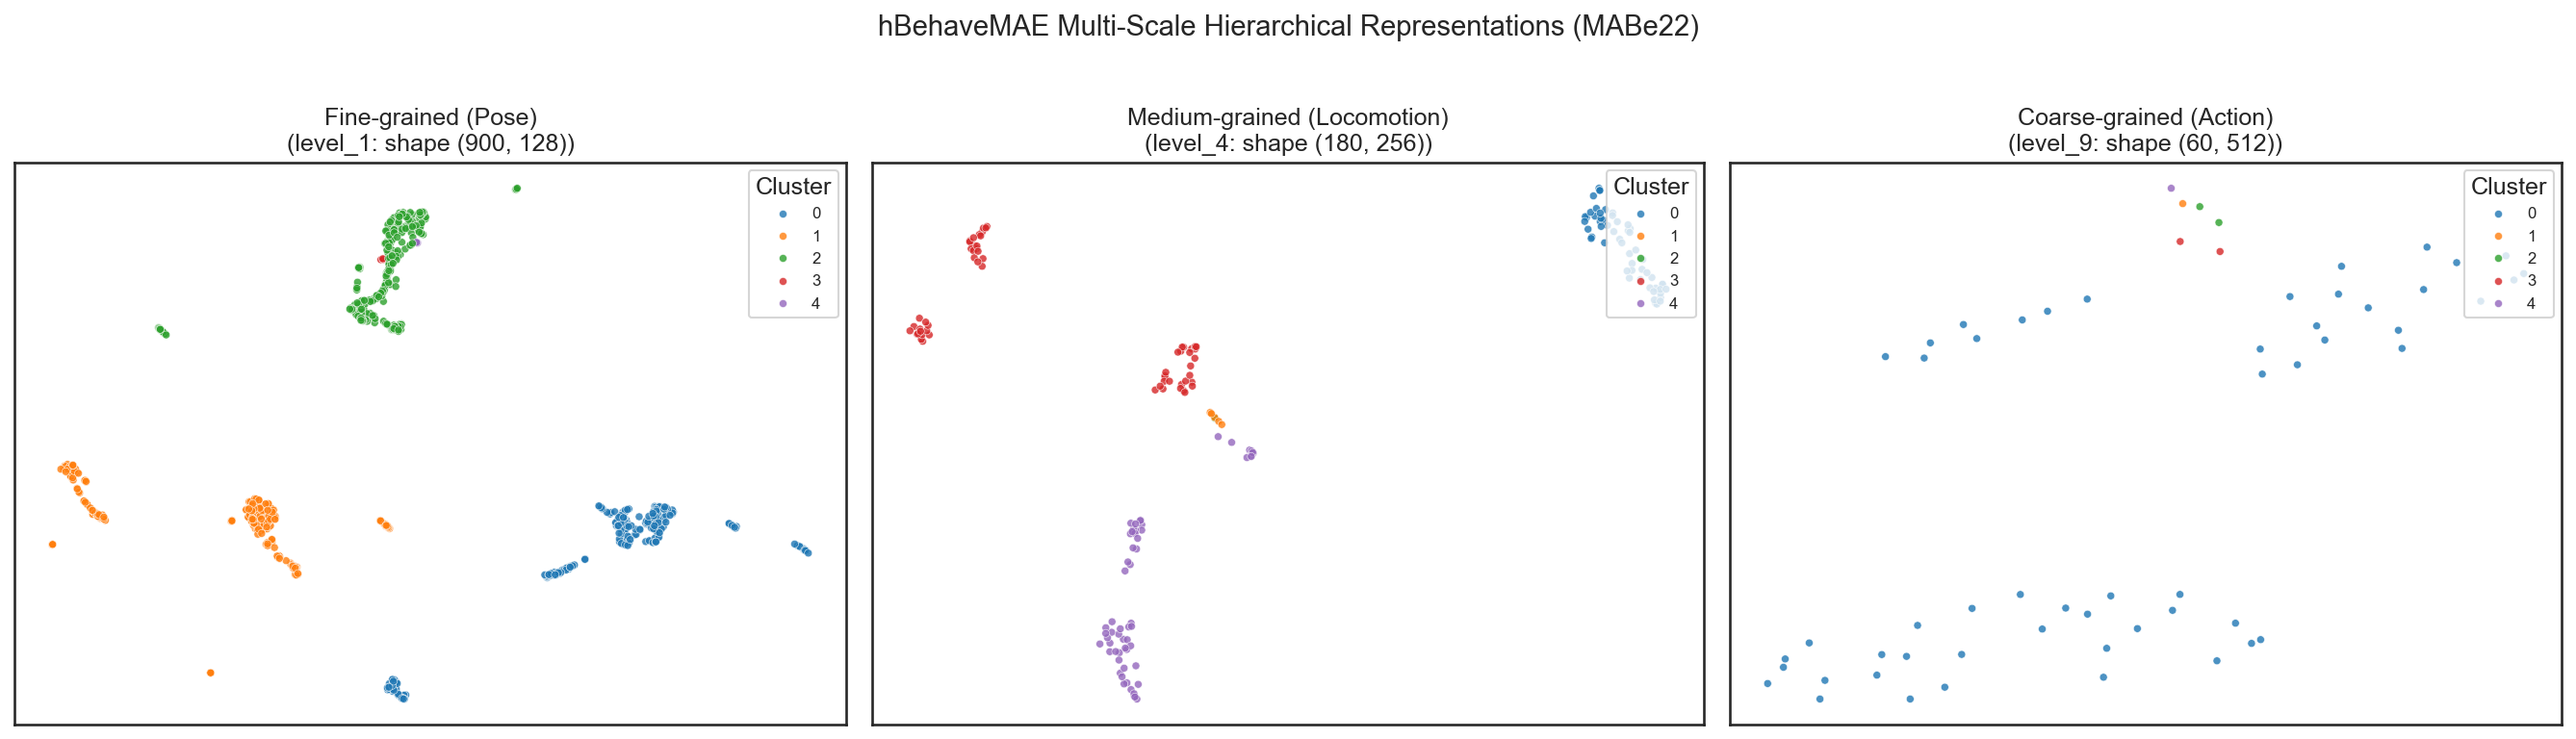

Saved visualization to: /Users/joon/dev/behavior-lab/outputs/calms21_behavior_discovery/behavemae_hierarchical_umap.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=DPI)

for i, (level_key, name) in enumerate(levels_to_compare.items()):
    emb = umap_results[level_key]
    labels = cluster_results[level_key]
    ax = axes[i]
    
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=labels,
                    palette="tab10", s=15, alpha=0.8, ax=ax, legend=True)
    ax.set_title(f"{name}\n({level_key}: shape {hier_features[level_key].shape})")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(title="Cluster", fontsize=8, loc="upper right")

fig.suptitle("hBehaveMAE Multi-Scale Hierarchical Representations (MABe22)", fontsize=14, y=1.02)
fig.tight_layout()

# Save to Outputs directory
save_path = OUT_ROOT / "behavemae_hierarchical_umap.png"
fig.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved visualization to: {save_path}")